# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [20]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Juan Carlos Orozco Nieto"            # Tu nombre completo
MATRICULA = "82168"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Juan Carlos Orozco Nieto
Matrícula: 82168
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [21]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\j_c_o\Documents\Salle\5to-semestre\bigdata\P1_examen_bigdata\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [23]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [24]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [25]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [26]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [27]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [28]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

En mi caso el dataset de alcohol no tiene valores nulos, lo que puede simplificar un poco el análisis, ya vienen los datos limpios. Nada más hay 4 columnas, el país, su código, año y valor, lo que también simplifica las cosas. Los tipos de datos son 2 de strings, 1 enteros (años) y 1 decimales (los valores, el atributo a estudiar). Por lo que se ve en este análisis inicial también parece que los registros son consistentes en tener aproximadamente ~20 años registrados por país.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [29]:
# Pregunta 1
# Tu codigo aqui
# Para recordar: las variables son entity, code, year, valor

# Asignar paises a df_paises con el config de arriba
df_paises = df[df[config["filtro_paises"]].notnull()]

# Cuántos países distintos hay
print(f"Cantidad de países: {df_paises['entity'].nunique()}")

# Mostrar los 10 países con mayor valor promedio de 'valor'
print("\nTop 10 altos:")
print(df_paises.groupby('entity')['valor'].mean().sort_values(ascending=False).head(10))

# Mostrar los 10 países con mayor valor promedio de 'valor'
print("\nTop 10 bajos:")
print(df_paises.groupby('entity')['valor'].mean().sort_values(ascending=True).head(10))

Cantidad de países: 189

Top 10 altos:
entity
Luxembourg     83.860467
Andorra        83.670942
Ireland        82.445061
Australia      80.434311
Switzerland    79.996778
New Zealand    79.544954
Austria        79.378880
Germany        78.765049
Finland        78.559587
Denmark        78.281563
Name: valor, dtype: float64

Top 10 bajos:
entity
Comoros         0.907852
Somalia         0.921273
Yemen           1.099488
Kuwait          1.317646
Libya           1.388956
Iran            1.485882
Pakistan        1.552597
Syria           1.596141
Mauritania      1.718631
Saudi Arabia    1.948948
Name: valor, dtype: float64


**Interpretación:**

En este bloque simplemente filtramos los países en una nueva variable df_paises, vemos cuántos países son (189) y filtramos los 10 más alto y los 10 más bajos. Como cada país tiene varios registros, para poder tomar los valores más altos y más bajos, primero hacemos un promedio de sus valores. 
Los resultados muestran datos muy diferentes, con promedios de hasta arriba de 80 en los más altos, mostrando principalmente países de primer mundo del continente europeo, y con promedios incluso menores a 1, mostrando principalmente países en África y Asia

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [30]:
# Pregunta 2
# Filtro por país y rango de años

# 1. Definir los dos países a comparar
pais_1 = "Mexico"
pais_2 = "Japan"

# 2. Filtrar los DataFrames individuales de cada país
df_mexico = df_paises[df_paises["entity"] == pais_1]
df_japon = df_paises[df_paises["entity"] == pais_2]

# 3. Encontrar la intersección de años disponibles para ambos (años comunes)
anios_comunes = np.intersect1d(df_mexico["year"], df_japon["year"])

print(f"Rango de años comunes para {pais_1} y {pais_2}:")
print(f"Desde el año {anios_comunes.min()} hasta {anios_comunes.max()} (Total: {len(anios_comunes)} años registrados)\n")

# 4. Filtrar df_paises para mostrar únicamente los datos de ambos países en esos años comunes
df_comparacion = df_paises[
    (df_paises["entity"].isin([pais_1, pais_2])) & 
    (df_paises["year"].isin(anios_comunes))
].sort_values(["year", "entity"])

# 5. Mostrar las primeras filas del resultado
print(f"Información filtrada de {pais_1} y {pais_2} (primeras 10 filas):")
display(df_comparacion.head(10))


Rango de años comunes para Mexico y Japan:
Desde el año 2000 hasta 2020 (Total: 21 años registrados)

Información filtrada de Mexico y Japan (primeras 10 filas):


,entity,code,year,valor
1806,Japan,JPN,2000,70.807230
2289,Mexico,MEX,2000,43.696823
1807,Japan,JPN,2001,69.746400
2290,Mexico,MEX,2001,43.486710
1808,Japan,JPN,2002,69.596890
2291,Mexico,MEX,2002,43.310062
1809,Japan,JPN,2003,69.430760
2292,Mexico,MEX,2003,43.456112
1810,Japan,JPN,2004,69.520980
2293,Mexico,MEX,2004,43.573890


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [31]:
# Pregunta 3
# Comparación entre 5 países de distintos continentes en el año más reciente

# 1. Definir 5 países de continentes distintos (América, Europa, Asia, África, Oceanía)
paises_elegidos = ["Mexico", "Germany", "Japan", "South Africa", "Australia"]

# 2. Obtener el año más reciente disponible en los datos
anio_mas_reciente = df_paises["year"].max()
print(f"Año más reciente disponible en el dataset: {anio_mas_reciente}\n")

# 3. Filtrar la información para los 5 países en ese año y ordenar de mayor a menor valor
df_5_paises = df_paises[
    (df_paises["entity"].isin(paises_elegidos)) & 
    (df_paises["year"] == anio_mas_reciente)
].copy().sort_values("valor", ascending=False)

# 4. Mostrar la lista ordenada de países y sus valores
print("Valores registrados en los 5 países (ordenados de mayor a menor):")
for _, fila in df_5_paises.iterrows():
    print(f"- {fila['entity']}: {fila['valor']:.2f}%")

# 5. Calcular país con el valor más alto, más bajo y la diferencia entre ambos
pais_maximo = df_5_paises.iloc[0]
pais_minimo = df_5_paises.iloc[-1]
diferencia_extremos = pais_maximo["valor"] - pais_minimo["valor"]

print(f"\nPaís con el valor más alto: {pais_maximo['entity']} con {pais_maximo['valor']:.2f}%")
print(f"País con el valor más bajo: {pais_minimo['entity']} con {pais_minimo['valor']:.2f}%")
print(f"Diferencia entre el más alto y el más bajo: {diferencia_extremos:.2f} puntos porcentuales")


Año más reciente disponible en el dataset: 2020

Valores registrados en los 5 países (ordenados de mayor a menor):
- Australia: 80.67%
- Germany: 78.83%
- Japan: 67.50%
- Mexico: 42.04%
- South Africa: 29.62%

País con el valor más alto: Australia con 80.67%
País con el valor más bajo: South Africa con 29.62%
Diferencia entre el más alto y el más bajo: 51.05 puntos porcentuales


**Interpretación:**

Aquí comparamos 5 países en base a su valor, y el análisis nos dice que de los 5, el más alto es Australia, con un 81% de gente mayor a 15 años que ha bebido alcohol en el último año, y el más bajo es Sudáfrica, con un 30%.
La diferencia es muy significativa, ya que hay más de un 50% entre el más alto y el más bajo, y de nuevo se puede observar que países de continentes como Europa y Oceanía encabezan el top, y el país africano es el más bajo.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [32]:
# Pregunta 4
# Comparación entre grupos (Latinoamérica vs Asia) en el año más reciente

# 1. Definir los países de cada grupo
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

# 2. Determinar el año más reciente disponible
anio_reciente = df_paises["year"].max()
print(f"Año más reciente analizado: {anio_reciente}\n")

# 3. Filtrar los registros de cada grupo para el año más reciente
df_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)]
df_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)]

# 4. Calcular el promedio del indicador para cada región
promedio_latam = df_latam["valor"].mean()
promedio_asia = df_asia["valor"].mean()

# 5. Mostrar los valores individuales y el promedio de cada grupo
print("Valores de Latinoamérica:")
for _, row in df_latam.iterrows():
    print(f"- {row['entity']}: {row['valor']:.2f}%")
print(f"Promedio de Latinoamérica: {promedio_latam:.2f}%\n")

print("Valores de Asia:")
for _, row in df_asia.iterrows():
    print(f"- {row['entity']}: {row['valor']:.2f}%")
print(f"Promedio de Asia: {promedio_asia:.2f}%\n")

# 6. Comparación de los promedios
diferencia_grupos = promedio_asia - promedio_latam
print(f"Diferencia (Asia - Latinoamérica): {diferencia_grupos:.2f} puntos porcentuales")


Año más reciente analizado: 2020

Valores de Latinoamérica:
- Argentina: 71.02%
- Colombia: 40.88%
- Mexico: 42.04%
Promedio de Latinoamérica: 51.31%

Valores de Asia:
- China: 60.26%
- Japan: 67.50%
- Vietnam: 53.70%
Promedio de Asia: 60.49%

Diferencia (Asia - Latinoamérica): 9.18 puntos porcentuales


**Interpretación:**

En este caso comparamos un fragmento de Latinoamérica con un fragmento de Asia, donde el resultado es ligeramente más alto para Asia, solamente 9 puntos porcentuales.
En el análisis podemos observar que los valores de Asia son más cercanos entre sí, lo que deja un promedio cercano a los valores iniciales (std bajo), y en los 3 de latinoamérica hay un poco más de variación, ya que el promedio sería un poco más bajo de no ser por Argentina, que cuenta con el valor más alto de los 6 países analizados, siendo un 29% mayor a los otros 2 países de su grupo. Esto mismo provoca que el promedio de latinoamérica suba, y se quede más cerca del promedio de Asia.
De cierta forma esta variación de resultados entre países del mismo grupo también nos sugiere que son muy pocos países para realmente poder comparar 2 regiones, y que necesitaríamos una muestra mucho más grande para compararlas correctamente.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [33]:
# Pregunta 5
# Análisis de tendencia temporal para un país (México)

# 1. Filtrar los registros históricos de México ordenados por año
pais_elegido = "Mexico"
df_pais = df_paises[df_paises["entity"] == pais_elegido].sort_values("year")

# 2. Encontrar el año con el valor máximo y el año con el valor mínimo
fila_max = df_pais.loc[df_pais["valor"].idxmax()]
fila_min = df_pais.loc[df_pais["valor"].idxmin()]

anio_max = int(fila_max["year"])
valor_max = fila_max["valor"]

anio_min = int(fila_min["year"])
valor_min = fila_min["valor"]

# 3. Mostrar resumen del análisis temporal
print(f"Análisis de tendencia temporal para {pais_elegido} ({int(df_pais['year'].min())} - {int(df_pais['year'].max())}):\n")
print(f"- Valor máximo registrado: {valor_max:.2f}% en el año {anio_max}")
print(f"- Valor mínimo registrado: {valor_min:.2f}% en el año {anio_min}")
print(f"- Variación total (máx - mín): {valor_max - valor_min:.2f} puntos porcentuales\n")

# 4. Mostrar la tabla con el historial de años y valores
print("Serie histórica de valores:")
print(df_pais[["year", "valor"]].to_string(index=False))


Análisis de tendencia temporal para Mexico (2000 - 2020):

- Valor máximo registrado: 44.07% en el año 2006
- Valor mínimo registrado: 41.94% en el año 2013
- Variación total (máx - mín): 2.13 puntos porcentuales

Serie histórica de valores:
 year     valor
 2000 43.696823
 2001 43.486710
 2002 43.310062
 2003 43.456112
 2004 43.573890
 2005 43.666603
 2006 44.073420
 2007 42.525486
 2008 42.630943
 2009 42.772570
 2010 42.275200
 2011 42.341488
 2012 42.171944
 2013 41.940746
 2014 42.286865
 2015 42.922820
 2016 43.080498
 2017 43.575916
 2018 43.875687
 2019 43.971450
 2020 42.036960


**Interpretación:**

Es una tendencia fluctuante, está constantemente bajando y subiendo, pero dentro de un rango muy constante. A lo largo de todos los años del estudio apenas se vió una variación total de 2.13%, lo que indica que históricamente el consumo de alcohol en México no ha cambiado mucho. EL valor máximo fue fue en el 2006 y el mínimo en 2013

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [34]:
# Pregunta 6
# Cambio porcentual para México entre el primer y último año disponible

# 1. Filtrar los datos de México ordenados cronológicamente
df_mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

# 2. Obtener el primer y el último registro de la serie temporal
registro_inicial = df_mexico.iloc[0]
registro_final = df_mexico.iloc[-1]

anio_inicial = int(registro_inicial["year"])
valor_inicial = registro_inicial["valor"]

anio_final = int(registro_final["year"])
valor_final = registro_final["valor"]

# 3. Calcular la diferencia absoluta y el cambio porcentual relativo
diferencia_absoluta = valor_final - valor_inicial
cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

# 4. Imprimir resultados descriptivos en español
print("Datos históricos de México:")
print(f"- Primer año ({anio_inicial}): {valor_inicial:.2f}%")
print(f"- Último año ({anio_final}): {valor_final:.2f}%\n")

print(f"Diferencia absoluta: {diferencia_absoluta:.2f} puntos porcentuales")
print(f"Cambio porcentual relativo: {cambio_porcentual:.2f}%\n")

# 5. Determinar si representa incremento o caída
if cambio_porcentual < 0:
    print(f"Resultado: Presenta una CAÍDA relativa de {abs(cambio_porcentual):.2f}%.")
elif cambio_porcentual > 0:
    print(f"Resultado: Presenta un INCREMENTO relativo de {abs(cambio_porcentual):.2f}%.")
else:
    print("Resultado: El indicador se mantuvo constante.")


Datos históricos de México:
- Primer año (2000): 43.70%
- Último año (2020): 42.04%

Diferencia absoluta: -1.66 puntos porcentuales
Cambio porcentual relativo: -3.80%

Resultado: Presenta una CAÍDA relativa de 3.80%.


**Interpretación:**

Ya habíamos analizado México en la pregunta anterior, por lo que tenemos aún más datos.
Los datos presentan una diferencia de -1.66 puntos en su valor, lo que significa una caída relativa entre ambos registros del 3.80%, pero como ya vimos en el análisis anterior, al tener méxico una serie de datos fluctuante y dentro de un rango constante, este valor tampoco significa que en general los datos vayan hacia abajo. Eso sumado a que el cambio relativo sigue siendo bajo, confirma el análisis anterior.
Creo que se ha mentenido así porque en general el consumo en México es muy estable, y las costumbres culturales suelen estar arraigadas, y las caídas pequeñas, como el valor ligeramente más bajo en 2020 se podrían explicar con eventos como la pandemia

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [35]:
# Pregunta 7
# Estadísticas descriptivas usando NumPy (no .describe() de pandas) para el año más reciente

# 1. Obtener el año más reciente disponible en df_paises
anio_reciente = df_paises["year"].max()

# 2. Filtrar únicamente los registros del año más reciente
df_reciente = df_paises[df_paises["year"] == anio_reciente]

# 3. Convertir la columna 'valor' a arreglo de NumPy y limpiar valores NaN
valores_np = df_reciente["valor"].to_numpy()
valores_limpios = valores_np[~np.isnan(valores_np)]

# 4. Calcular media, mediana y desviación estándar usando funciones de NumPy
media = np.mean(valores_limpios)
mediana = np.median(valores_limpios)
desv_estandar = np.std(valores_limpios)

# 5. Mostrar resultados en español con formato claro
print(f"Estadísticas descriptivas con NumPy para el año {anio_reciente} ({len(valores_limpios)} países analizados):\n")
print(f"- Media (promedio): {media:.2f}%")
print(f"- Mediana (valor central): {mediana:.2f}%")
print(f"- Desviación estándar (dispersión): {desv_estandar:.2f}%")


Estadísticas descriptivas con NumPy para el año 2020 (187 países analizados):

- Media (promedio): 42.25%
- Mediana (valor central): 42.04%
- Desviación estándar (dispersión): 24.00%


**Interpretación:**

La media y la mediana tienen valores muy similares, por lo que parece una distribución bastante simétrica, pero como habíamos visto en pruebas anteriores, los datos son muy variados, y hay mucha diferencia entre los países con promedios más altos y más bajos, lo que también provoca una desviación estándar bastante alta del 24%, y nos indica que el promedio puede llegar a ser un poco engañoso debido a la variación de los datos


### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

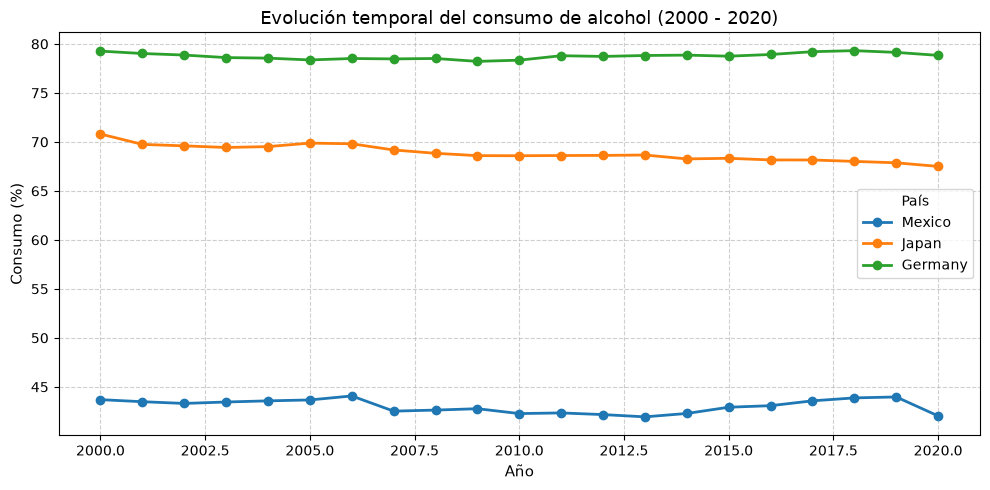

In [36]:
# Pregunta 8
# Visualización de la evolución temporal con matplotlib para 3 países

# 1. Definir los 3 países a graficar
paises_grafica = ["Mexico", "Japan", "Germany"]

# 2. Crear la figura
plt.figure(figsize=(10, 5))

# 3. Graficar la línea de cada país a lo largo de los años
for pais in paises_grafica:
    df_sub = df_paises[df_paises["entity"] == pais].sort_values("year")
    plt.plot(
        df_sub["year"],
        df_sub["valor"],
        marker="o",
        linewidth=2,
        label=pais
    )

# 4. Configurar etiquetas, título, cuadrícula y leyenda
plt.title(f"Evolución temporal del consumo de alcohol (2000 - 2020)", fontsize=13)
plt.xlabel("Año", fontsize=11)
plt.ylabel(f"Consumo ({config['unidad']})", fontsize=11)
plt.legend(title="País")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Interpretación:**

En la gráfica podemos ver los datos de Japón, Alemania y México, 3 países que ya habíamos analizado antes. La gráfica muestra que los 3 son bastante consistentes, y mantienen una línea casi horizontal, por lo que sabemos que su consumo no ha cambiado mucho con el paso de los años

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

Nota: El año 2023 no cuenta con datos en este dataset.
Se utiliza el año más reciente disponible (2020) para comparar con 2006.



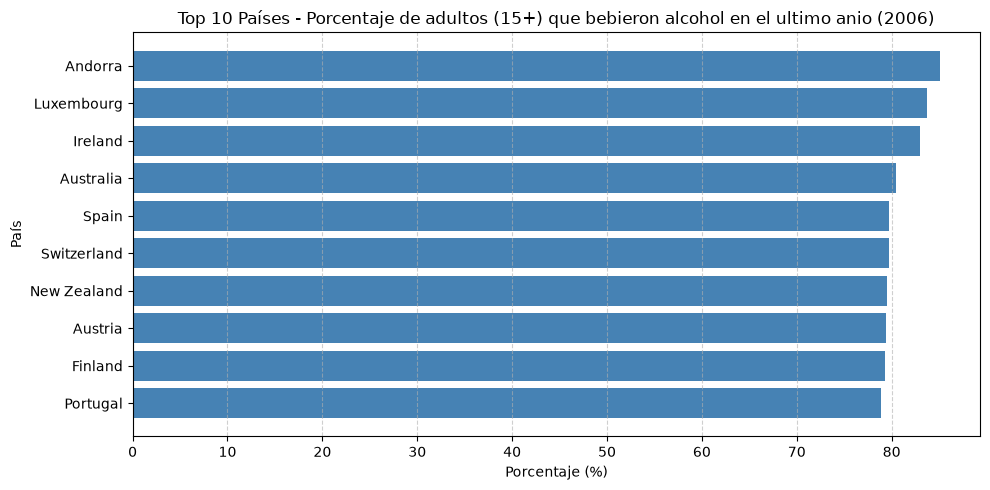

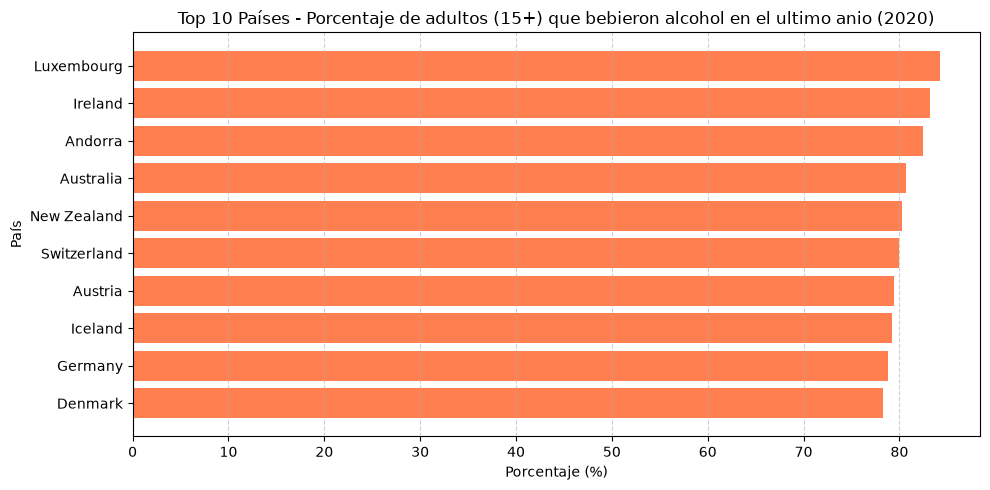

In [38]:
# Pregunta 9
# Visualización integradora: Top 10 países en año de nacimiento vs año más reciente (2020/2023)

# 1. Definir año de nacimiento y año objetivo
anio_nacimiento = 2006
anio_objetivo = 2023

# Si el año 2023 no está disponible en este dataset, utilizar el año más reciente registrado (2020)
if anio_objetivo in df_paises["year"].values:
    anio_segundo = anio_objetivo
else:
    anio_segundo = int(df_paises["year"].max())
    print(f"Nota: El año {anio_objetivo} no cuenta con datos en este dataset.")
    print(f"Se utiliza el año más reciente disponible ({anio_segundo}) para comparar con {anio_nacimiento}.\n")

# 2. Obtener el Top 10 para el año de nacimiento (2002)
top_nacimiento = (
    df_paises[df_paises["year"] == anio_nacimiento]
    .sort_values("valor", ascending=False)
    .head(10)
)

# 3. Obtener el Top 10 para el segundo año (2020)
top_segundo = (
    df_paises[df_paises["year"] == anio_segundo]
    .sort_values("valor", ascending=False)
    .head(10)
)

# 4. Gráfica 1: Top 10 en el año de nacimiento (2002)
plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
plt.xlabel(f"Porcentaje ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 Países - {config['descripcion']} ({anio_nacimiento})")
plt.gca().invert_yaxis()  # El valor más alto arriba
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Gráfica 2: Top 10 en el año más reciente ({anio_segundo})
plt.figure(figsize=(10, 5))
plt.barh(top_segundo["entity"], top_segundo["valor"], color="coral")
plt.xlabel(f"Porcentaje ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 Países - {config['descripcion']} ({anio_segundo})")
plt.gca().invert_yaxis()  # El valor más alto arriba
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


**Interpretación:**

Esta gráfica confirma lo que hemos visto a lo largo del documento, que los datos son consitentes a lo largo de los años. Aunque ha habido algunos cambios y rotaciones en el podio, como andorra que bajó del primer puesto al tercero, o Portugal y España que salieron de la gráfica, la mayoría de los países de la gráfica inicial se mantienen en la segunda gráfica, y todos se mantienen con datos similares cercanos al 80%

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Trabajar con este dataset fue bastante cómodo porque los datos resultaron ser muy consistentes: casi todos los países tienen exactamente los mismos 21 años registrados (de 2000 a 2020) y no hay valores nulos, lo que evitó tener que limpiar los datos o realizar correcciones.
Como patrones pude observar una alta variación entre los países con valores más altos y más bajos, y que consistentemente los países europeos con ingresos altos suelen ocupar las primeras posiciones del top, mientras que países de África y Medio Oriente suelen tener valores más bajos. Estos datos por si solos tampoco nos dan una conclusión fija, pero si sugieren que factores como la economía, la cultura o la religión pueden ser los que marquen estas diferencias.
Las principales limitaciones creo que son que los datos son un poco ambiguos, solamente miden si una persona tomó alcohol en el último año, pero no mencionan cuánto tomó ni qué tan seguido, por lo que una bebida al año vale lo mismo que alguien que toma todos los días.
Si tuviera más tiempo podríamos comparar los datos con otros datasets relativos a la cantidad de alcohol consumida por país, o compararlos con datasets referentes a datos como economía, cultura o religión para buscar patrones y relaciones entre sí.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
